In [14]:
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

def alphaCalc(N):
    return 2 / (N + 1)

data = pd.read_csv('Bitcoin-Historical-Data.csv')
data

,Date,Price,Open,High,Low,Vol.,Change %
0,01/01/2023,"16,618.4","16,537.5","16,621.9","16,499.7",107.84K,0.49%
1,12/31/2022,"16,537.4","16,607.2","16,635.9","16,487.3",130.44K,-0.42%
2,12/30/2022,"16,607.2","16,636.4","16,644.4","16,360.0",192.76K,-0.18%
3,12/29/2022,"16,636.4","16,546.2","16,659.1","16,496.6",181.47K,0.55%
4,12/28/2022,"16,546.2","16,705.9","16,781.1","16,474.2",217.96K,-0.96%
...,...,...,...,...,...,...,...
3648,01/05/2013,13.4,13.5,13.6,13.3,21.33K,-0.44%
3649,01/04/2013,13.5,13.4,13.5,13.3,29.64K,0.75%
3650,01/03/2013,13.4,13.3,13.5,13.3,18.03K,0.90%
3651,01/02/2013,13.3,13.3,13.4,13.2,17.97K,0.00%


In [4]:
def subArrays(arr1, arr2):
    resultArr = []
    length = len(arr1)
    if len(arr2)<length:
        length = len(arr2)
    for i in range(0, length):
        resultArr.append(arr1[i]-arr2[i])
    return resultArr

In [5]:
def EMA_element_calc(data, N, nmb_of_curr_elem):
    alpha=alphaCalc(N)
    emaNumerator = data[nmb_of_curr_elem]
    emaDenominator =1
    for j in range(1,nmb_of_curr_elem):
        emaNumerator += ((1-alpha)**j)*data[nmb_of_curr_elem-j]
        emaDenominator += (1-alpha)**j
    return emaNumerator/emaDenominator


In [6]:

def EMA_calc(data, N):
    EMAs_array = []
    for i in range(0,len(data)): #through all numbers
        emaElem =0
        if i<N: #check if actual address in array is less than N then nmb of elements equals i
            emaElem = EMA_element_calc(data, N, i)
        else: #if actual address higher or equal to N then nmb of elements equals N
            emaElem = EMA_element_calc(data, N, N)
        EMAs_array.append(emaElem)
    return EMAs_array


In [7]:
def toFloats(array):
    float_array = []
    for i in array:
        item = float(i.replace(',',''))
        float_array.append(item)
    return float_array

In [11]:
def intersectionPoints(MACD, SIGNAL):
    intersection = []
    buy = []
    sell = []
    for i in range(1, len(MACD)): #skip first because there is no way to analyse if it would be buy or sell
        if MACD[i]==SIGNAL[i]:
            intersection.append(i) #add id in MACD array to intersection array
            if MACD[i-1]>SIGNAL[i-1]:
                sell.append(i)
            else:
                buy.append(i)       
    return intersection, buy, sell

In [8]:


data_from_csv = pd.read_csv('Bitcoin-Historical-Data.csv')
data_for_calc = data_from_csv['Price']

data_for_calc

0       16,618.4
1       16,537.4
2       16,607.2
3       16,636.4
4       16,546.2
          ...   
3648        13.4
3649        13.5
3650        13.4
3651        13.3
3652        13.3
Name: Price, Length: 3653, dtype: object

In [9]:
data_for_calc = toFloats(data_for_calc)


In [10]:
EMA12 = EMA_calc(data_for_calc, 12)
EMA26 = EMA_calc(data_for_calc,26)
MACD = subArrays(EMA12,EMA26)
SIGNAL = EMA_calc(MACD,9)

In [12]:
intersectPoints, buyArray, sellArray = intersectionPoints(MACD, SIGNAL)


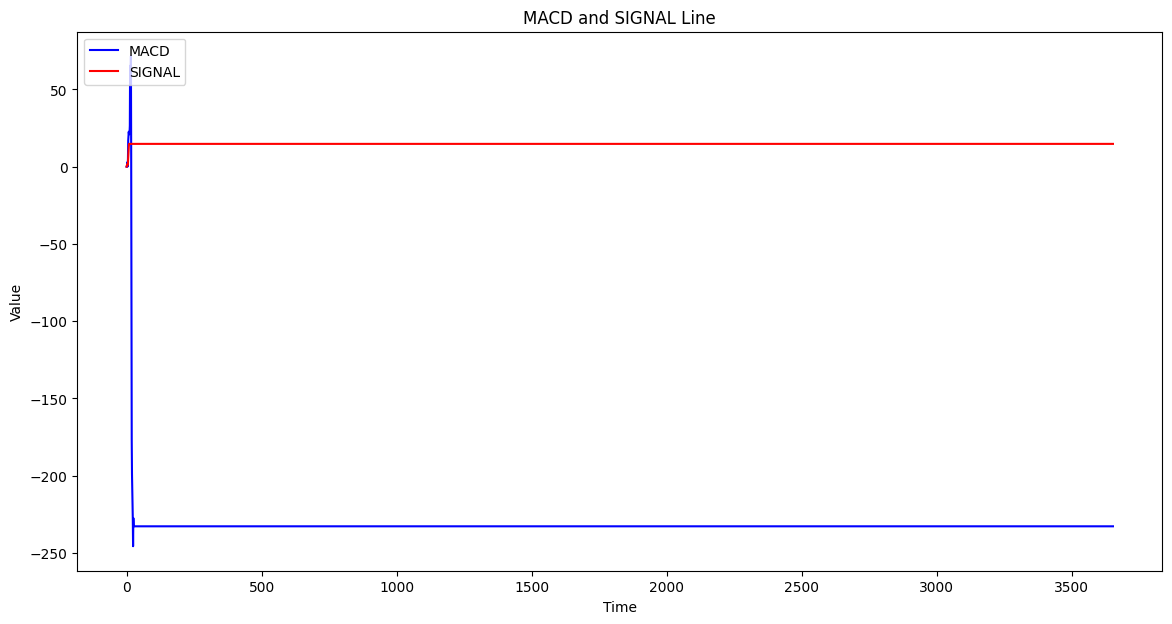

In [15]:
plt.figure(figsize=(14,7))
plt.plot(MACD, label='MACD', color='blue')
plt.plot(SIGNAL, label='SIGNAL', color='red')
plt.legend(loc='upper left')
plt.title('MACD and SIGNAL Line')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()